In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [71]:
def Trans_min(amplitude_after_loss, coupling):
    """
    Calculate the minimum transmission based on loss and coupling.

    Parameters:
    loss (float): The loss value.
    coupling (float): The coupling value.

    Returns:
    float: The minimum transmission.
    """
    return (amplitude_after_loss - coupling) ** 2 / (1 - amplitude_after_loss * coupling) ** 2

def build_up_max(amplitude_after_loss, coupling):
    """
    Calculate the maximum build-up based on loss and coupling.

    Parameters:
    loss (float): The loss value.
    coupling (float): The coupling value.

    Returns:
    float: The maximum build-up.
    """
    return (1-coupling**2)/ (1-amplitude_after_loss*coupling)**2

In [ ]:
loss = 0.9  # Example loss value
coupling_values = np.linspace(0, 1, 100)  # Coupling values from 0 to 1

In [73]:
loss = 0.995
print("Amplitude after loss:", loss)
for coupling in [0.999,0.995,0.990]:
    print(f"Coupling: {coupling}, Transmission: {Trans_min(loss, coupling)}")

print("\n")
for coupling in [0.999,0.995,0.990]:
    print(f"Coupling: {coupling}, Build-up: {build_up_max(loss, coupling)}")

Amplitude after loss: 0.995
Coupling: 0.999, Transmission: 0.4451861121409954
Coupling: 0.995, Transmission: 0.0
Coupling: 0.99, Transmission: 0.11185557208532335


Coupling: 0.999, Build-up: 55.62043988561476
Coupling: 0.995, Build-up: 100.25062656641649
Coupling: 0.99, Build-up: 89.03703537991736


In [18]:
def transmission_frequency(loss, coupling, frequency, f0, FSR_f):
    """
    Calculate the transmission as a function of frequency.

    Parameters:
    loss (float): The loss value.
    coupling (float): The coupling value.
    frequency (float): The frequency at which to calculate the transmission.
    f0 (float): The resonant frequency.
    Q (float): The quality factor.

    Returns:
    float: The transmission at the specified frequency.
    """
    delta_f = frequency - f0

    numerator =  (1-loss**2) * (1-coupling**2)

    denominator = (1-loss*coupling)**2 + 4 * loss*coupling * np.sin(2*np.pi*delta_f/(2*FSR_f) )**2

    return 1 -  numerator / denominator




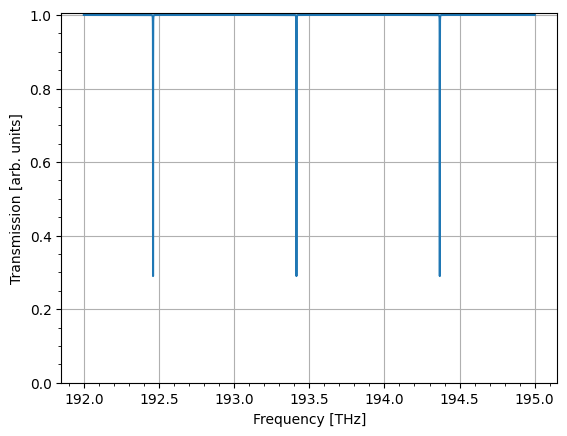

In [40]:
coupling = 0.999
a = 0.9997
f_0 = 193.4145e12  # Resonant frequency in Hz
FSR_f = 954e9  # Free Spectral Range in Hz

frequencies = np.linspace(192e12, 195e12, 1000000)
transmissions = transmission_frequency(a, coupling, frequencies, f_0, FSR_f)

plt.plot(frequencies*1e-12, transmissions)
plt.grid()
plt.xlabel("Frequency [THz]")
plt.ylabel("Transmission [arb. units]")
plt.ylim(0, 1.005)
plt.minorticks_on()

# plt.xlim(193.4e12, 193.42e12)

In [64]:
frequencies[half_max_indices]

array([1.92460305e+14, 1.92460308e+14, 1.92460311e+14, 1.92460314e+14,
       1.92460317e+14, 1.92460320e+14, 1.92460323e+14, 1.92460326e+14,
       1.92460329e+14, 1.92460332e+14, 1.92460335e+14, 1.92460338e+14,
       1.92460341e+14, 1.92460344e+14, 1.92460347e+14, 1.92460350e+14,
       1.92460353e+14, 1.92460356e+14, 1.92460359e+14, 1.92460362e+14,
       1.92460365e+14, 1.92460368e+14, 1.92460371e+14, 1.92460374e+14,
       1.92460377e+14, 1.92460380e+14, 1.92460383e+14, 1.92460386e+14,
       1.92460389e+14, 1.92460392e+14, 1.92460395e+14, 1.92460398e+14,
       1.92460401e+14, 1.92460404e+14, 1.92460407e+14, 1.92460410e+14,
       1.92460413e+14, 1.92460416e+14, 1.92460419e+14, 1.92460422e+14,
       1.92460425e+14, 1.92460428e+14, 1.92460431e+14, 1.92460434e+14,
       1.92460437e+14, 1.92460440e+14, 1.92460443e+14, 1.92460446e+14,
       1.92460449e+14, 1.92460452e+14, 1.92460455e+14, 1.92460458e+14,
       1.92460461e+14, 1.92460464e+14, 1.92460467e+14, 1.92460470e+14,
      

394.0003940101633 MHz


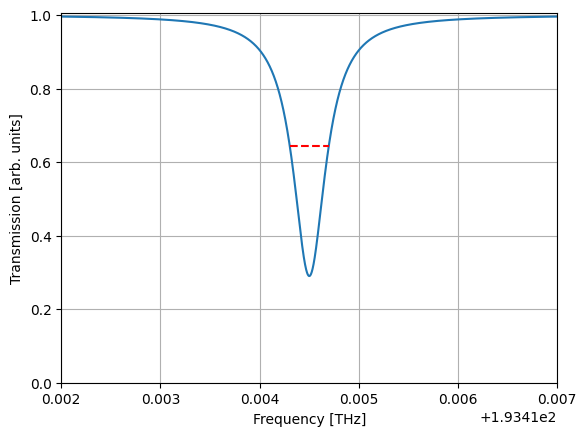

In [70]:
coupling = 0.999
a = 0.9997
f_0 = 193.4145e12  # Resonant frequency in Hz
FSR_f = 954e9  # Free Spectral Range in Hz

frequencies = np.linspace(193e12, 194e12, 1000000)
transmissions = transmission_frequency(a, coupling, frequencies, f_0, FSR_f)


min_index = np.where(transmissions == np.min(transmissions))

half_max = 1-(1-transmissions[min_index])/2

half_max_indices = np.where(transmissions < half_max)

freq_1 = np.min(frequencies[half_max_indices])*1e-12
freq_2 = np.max(frequencies[half_max_indices])*1e-12



plt.plot(frequencies*1e-12, transmissions)
plt.grid()
plt.xlabel("Frequency [THz]")
plt.ylabel("Transmission [arb. units]")
plt.ylim(0, 1.005)
# plt.minorticks_on()
plt.hlines(half_max,xmin=freq_1, xmax=freq_2, colors='r', linestyles='dashed', label='50% Transmission')

plt.xlim(193.412, 193.417)

print((freq_2-freq_1)*1e6, "MHz")